# Week 4 — Cascaded Control + Discretization

Real propulsion control is layered.

A simple electric-drive version is:

**speed command → speed PI → torque/current command → fast inner loop → motor → measured speed**

The inner loop should be much faster than the outer loop, so the outer loop can approximately treat it as an ideal actuator.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PI:
    def __init__(self, kp, ki, umin=-np.inf, umax=np.inf):
        self.kp, self.ki = kp, ki
        self.umin, self.umax = umin, umax
        self.integral = 0.0

    def step(self, error, dt):
        self.integral += error*dt
        return np.clip(self.kp*error + self.ki*self.integral, self.umin, self.umax)

dt = 0.0005
t = np.arange(0, 3, dt)

# Outer speed loop
speed_pi = PI(kp=0.25, ki=1.5, umin=-3, umax=3)

# Inner torque/current loop, represented by first-order actuator
tau_inner = 0.01
torque_actual = 0.0

J, b = 0.05, 0.02
omega = 0.0
omega_cmd = 30.0

W, Tc, Ta = [], [], []

for ti in t:
    load = 0.4 if ti < 1.5 else 0.9

    torque_cmd = speed_pi.step(omega_cmd-omega, dt)

    # Fast inner loop
    torque_actual += ((torque_cmd-torque_actual)/tau_inner)*dt

    # Mechanical plant
    omega += ((torque_actual-load-b*omega)/J)*dt

    W.append(omega); Tc.append(torque_cmd); Ta.append(torque_actual)

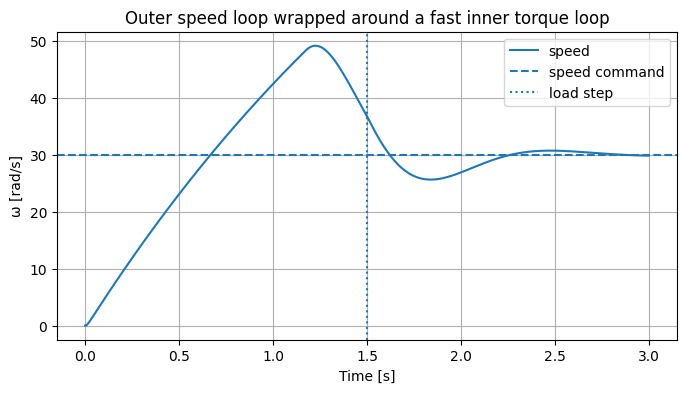

In [3]:
plt.figure(figsize=(8,4))
plt.plot(t, W, label="speed")
plt.axhline(omega_cmd, linestyle="--", label="speed command")
plt.axvline(1.5, linestyle=":", label="load step")
plt.xlabel("Time [s]")
plt.ylabel("ω [rad/s]")
plt.title("Outer speed loop wrapped around a fast inner torque loop")
plt.legend()
plt.grid(True)
plt.show()

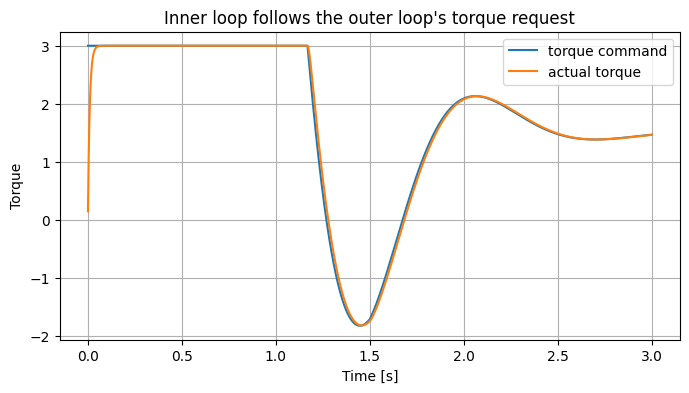

In [4]:
plt.figure(figsize=(8,4))
plt.plot(t, Tc, label="torque command")
plt.plot(t, Ta, label="actual torque")
plt.xlabel("Time [s]")
plt.ylabel("Torque")
plt.title("Inner loop follows the outer loop's torque request")
plt.legend()
plt.grid(True)
plt.show()

## Continuous → discrete

The embedded controller does not continuously integrate differential equations. It samples.

For

\[
\dot x=Ax+Bu
\]

the exact zero-order-hold discrete model is

\[
x_{k+1}=\Phi x_k+\Gamma u_k
\]

with

\[
\Phi=e^{A\Delta t}
\]

The matrix exponential is simply the continuous natural response evaluated one sample later.

In [5]:
from scipy.linalg import expm

A1 = np.array([[-2.0]])
B1 = np.array([[1.0]])
dt_d = 0.1

Phi = expm(A1*dt_d)
Gamma = np.linalg.solve(A1, (Phi-np.eye(1))) @ B1

print("Phi =", Phi)
print("Gamma =", Gamma)
print("Continuous pole:", -2.0)
print("Discrete pole:", float(Phi[0,0]))
print("Expected exp(-2*0.1) =", np.exp(-0.2))

Phi = [[0.81873075]]
Gamma = [[0.09063462]]
Continuous pole: -2.0
Discrete pole: 0.8187307530779818
Expected exp(-2*0.1) = 0.8187307530779818


**This is the bridge to hardware:** once the plant/controller is discrete, the same update law can run every sample on a microcontroller.